# 🧮 Quantitative Finance Python Toolkit
### Five cutting-edge libraries for derivatives, PDEs, Bayesian inference, convex optimisation & differentiable SDEs

| # | Library | One-liner |
|---|---------|-----------|
| 1 | **Diffrax** | Differentiable ODE/SDE solvers (JAX) |
| 2 | **py-pde** | PDE solver in five lines |
| 3 | **CVXPY** | Convex optimisation in readable math |
| 4 | **NumPyro** | Bayesian inference, fast |
| 5 | **FinancePy** | Full derivatives library |

> **Prerequisites** — run the install cell below once, then restart the kernel.


## 📦 Installation

In [1]:
# Install all five libraries + data helpers
import subprocess, sys

pkgs = [
    "diffrax", "jax", "jaxlib",
    "py-pde",
    "cvxpy",
    "numpyro",
    "FinancePy",
    "yfinance", "pandas", "matplotlib", "numpy", "scipy",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)
print("✅ All packages installed")


✅ All packages installed


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.1 requires numpy<2,>=1; python_version < "3.12", but you have numpy 2.0.2 which is incompatible.
langchain-community 0.3.1 requires numpy<2,>=1; python_version < "3.12", but you have numpy 2.0.2 which is incompatible.
pytorch-metric-learning 2.6.0 requires numpy<2.0, but you have numpy 2.0.2 which is incompatible.


In [3]:
# Standard imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import yfinance as yf
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "lines.linewidth":  1.8,
    "font.family":      "monospace",
})
print("✅ Imports OK")


✅ Imports OK


---
## 1 · DIFFRAX — Differentiable SDEs
*github.com/patrick-kidger/diffrax*

### Concept

Diffrax solves **ODEs, SDEs and CDEs** built on JAX.  
Every solver is *fully differentiable*, meaning gradients flow backwards  
through the entire Monte-Carlo path — enabling calibration as a single  
`jax.grad` call rather than a grid search.

#### Heston Stochastic Volatility Model

$$
dS_t = r S_t \, dt + \sqrt{v_t} \, S_t \, dW^S_t
$$
$$
dv_t = \kappa(\bar v - v_t)\,dt + \xi\sqrt{v_t}\,dW^v_t, \qquad
d\langle W^S, W^v \rangle = \rho \, dt
$$

| Parameter | Role |
|-----------|------|
| $\kappa$ | Mean-reversion speed |
| $\bar v$ | Long-run variance |
| $\xi$ | Vol-of-vol |
| $\rho$ | Spot-vol correlation |

**Forward**: price a European call via $C = e^{-rT}\mathbb{E}[(S_T-K)^+]$  
**Backward**: calibrate $\Theta^\star = \arg\min_\Theta \sum_k (C^{\text{model}}_k - C^{\text{mkt}}_k)^2$


In [1]:
# ── Diffrax: Heston Monte-Carlo pricer ──────────────────────────────────────
import jax
import jax.numpy as jnp
import diffrax

jax.config.update("jax_enable_x64", True)

# Heston parameters
KAPPA, V_BAR, XI, RHO = 2.0, 0.04, 0.3, -0.7
S0, V0, R, T = 100.0, 0.04, 0.02, 1.0
N_PATHS, N_STEPS = 4000, 252

def heston_paths(key, kappa=KAPPA, v_bar=V_BAR, xi=XI, rho=RHO,
                 s0=S0, v0=V0, r=R, T=T):
    ts = jnp.linspace(0.0, T, N_STEPS + 1)
    chol = jnp.array([[1.0, 0.0], [rho, jnp.sqrt(1 - rho**2)]])

    def drift(t, y, _):
        s, v = y
        v_pos = jnp.maximum(v, 1e-6)
        return jnp.array([r * s, kappa * (v_bar - v_pos)])

    def diffusion(t, y, _):
        s, v = y
        v_pos = jnp.maximum(v, 1e-6)
        sv = jnp.sqrt(v_pos)
        raw = jnp.array([[sv * s, 0.0], [0.0, xi * sv]])
        return raw @ chol

    def simulate(key):
        bm = diffrax.VirtualBrownianTree(0.0, T, tol=1e-3,
                                          shape=(2,), key=key)
        terms  = diffrax.MultiTerm(diffrax.ODETerm(drift),
                                   diffrax.ControlTerm(diffusion, bm))
        sol    = diffrax.diffeqsolve(terms, diffrax.Heun(), 0.0, T,
                                     T / N_STEPS, jnp.array([s0, v0]),
                                     saveat=diffrax.SaveAt(ts=ts))
        return sol.ys[:, 0]   # S path only

    keys  = jax.random.split(key, N_PATHS)
    paths = jax.vmap(simulate)(keys)
    return paths, ts

key = jax.random.PRNGKey(42)
paths, ts = heston_paths(key)
print(f"Paths shape: {paths.shape}   (paths × time-steps)")
print(f"Mean final S: {paths[:, -1].mean():.2f}")

# ── Price a call ─────────────────────────────────────────────────────────────
K = 100.0
payoffs   = jnp.maximum(paths[:, -1] - K, 0.0)
call_mc   = float(jnp.exp(-R * T) * payoffs.mean())
print(f"\nMC call price (K={K}): ${call_mc:.4f}")


RuntimeError: This version of jaxlib was built using AVX instructions, which your CPU and/or operating system do not support. This error is frequently encountered on macOS when running an x86 Python installation on ARM hardware. In this case, try installing an ARM build of Python. Otherwise, you may be able work around this issue by building jaxlib from source.

In [ ]:
# ── Plot Monte-Carlo fan ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ts_np = np.array(ts)
paths_np = np.array(paths)

ax = axes[0]
for p in paths_np[:120]:
    ax.plot(ts_np, p, alpha=0.07, color="#58a6ff", lw=0.6)
ax.plot(ts_np, paths_np.mean(axis=0), color="#f0883e", lw=2.2, label="mean path")
ax.set(title="Heston Monte-Carlo — S paths", xlabel="Time (years)", ylabel="S")
ax.legend()

# Payoff distribution
ax2 = axes[1]
ax2.hist(np.array(payoffs), bins=60, color="#3fb950", edgecolor="#161b22", alpha=0.85)
ax2.axvline(float(payoffs.mean()), color="#f85149", lw=2, label=f"Mean payoff = {float(payoffs.mean()):.2f}")
ax2.set(title=f"Call payoff distribution (K={K})", xlabel="Payoff", ylabel="Count")
ax2.legend()

plt.tight_layout()
plt.savefig("/tmp/diffrax_heston.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Diffrax Heston simulation complete")


In [ ]:
# ── Real-world data: fit Heston to SPY implied-vol chain via yfinance ────────
import yfinance as yf

spy = yf.Ticker("SPY")
hist = spy.history(period="2y")["Close"]

# Compute 1-year realised variance as proxy for v0
log_ret = np.log(hist / hist.shift(1)).dropna()
realised_var = float(log_ret[-252:].var() * 252)
S0_real = float(hist.iloc[-1])
print(f"SPY last close : ${S0_real:.2f}")
print(f"1Y realised variance (v0): {realised_var:.4f}  (vol ≈ {np.sqrt(realised_var)*100:.1f}%)")

# Price ATM call with fitted v0
paths_real, _ = heston_paths(jax.random.PRNGKey(0), v0=realised_var, s0=S0_real)
payoffs_real  = jnp.maximum(paths_real[:, -1] - S0_real, 0.0)
atm_call      = float(jnp.exp(-R * T) * payoffs_real.mean())
print(f"Heston ATM 1Y call on SPY: ${atm_call:.2f}")


---
## 2 · py-pde — PDEs in Five Lines
*github.com/zwicker-group/py-pde*

### Concept

`py-pde` writes a PDE as a Python expression and auto-selects a stable  
finite-difference scheme (explicit **or** implicit). No stencil coding needed.

#### Black-Scholes PDE (Dupire local-vol form)

The B-S PDE for a European option price $V(S,t)$:

$$
\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
+ r S \frac{\partial V}{\partial S} - r V = 0
$$

We solve the **heat-equation equivalent** (standard change of variables $x = \ln S$):

$$
\frac{\partial u}{\partial \tau} = \frac{\sigma^2}{2}\frac{\partial^2 u}{\partial x^2}
+ \left(r - \frac{\sigma^2}{2}\right)\frac{\partial u}{\partial x} - r\,u
$$

which `py-pde` solves directly in **five lines**.


In [4]:
# ── py-pde: Black-Scholes heat equation ──────────────────────────────────────
import pde

# Parameters
sigma, r, T_bs = 0.20, 0.05, 1.0
K_bs = 100.0

# Grid in log-price space: x = ln(S/K)
x_min, x_max, nx = -1.5, 1.5, 300
grid = pde.CartesianGrid([[x_min, x_max]], [nx], periodic=False)

# Initial condition = call payoff in log-price coords
x_vals = np.linspace(x_min, x_max, nx)
S_vals  = K_bs * np.exp(x_vals)
payoff  = np.maximum(S_vals - K_bs, 0.0)
state   = pde.ScalarField(grid, data=payoff)

# PDE: ∂u/∂τ = (σ²/2)∂²u/∂x² + (r-σ²/2)∂u/∂x - r·u
drift = r - 0.5 * sigma**2
eq = pde.PDE({
    "u": f"{0.5*sigma**2} * d2_dx2(u) + {drift} * d_dx(u) - {r} * u"
})

# Solve backward in τ (time-to-expiry)
sol = eq.solve(state, t_range=T_bs, dt=1e-4, tracker=None)
bs_pde_price_grid = sol.data

# Compare with closed-form B-S at S = K (ATM)
from scipy.stats import norm
d1 = (np.log(1.0) + (r + 0.5*sigma**2)*T_bs) / (sigma*np.sqrt(T_bs))
d2 = d1 - sigma*np.sqrt(T_bs)
bs_exact = K_bs*(np.exp(-r*T_bs)*norm.cdf(d1) - norm.cdf(d2))   # put-call parity gone; this is call
bs_exact = K_bs*(norm.cdf(d1) - np.exp(-r*T_bs)*norm.cdf(d2))

atm_idx   = np.argmin(np.abs(x_vals))  # x ≈ 0  →  S ≈ K
bs_pde_atm = float(bs_pde_price_grid[atm_idx]) * np.exp(-r*T_bs)
print(f"py-pde  ATM call : ${bs_pde_atm:.4f}")
print(f"B-S exact ATM    : ${bs_exact:.4f}")
print(f"Error            : ${abs(bs_pde_atm - bs_exact):.4f}")


py-pde  ATM call : $9.6781
B-S exact ATM    : $10.4506
Error            : $0.7725


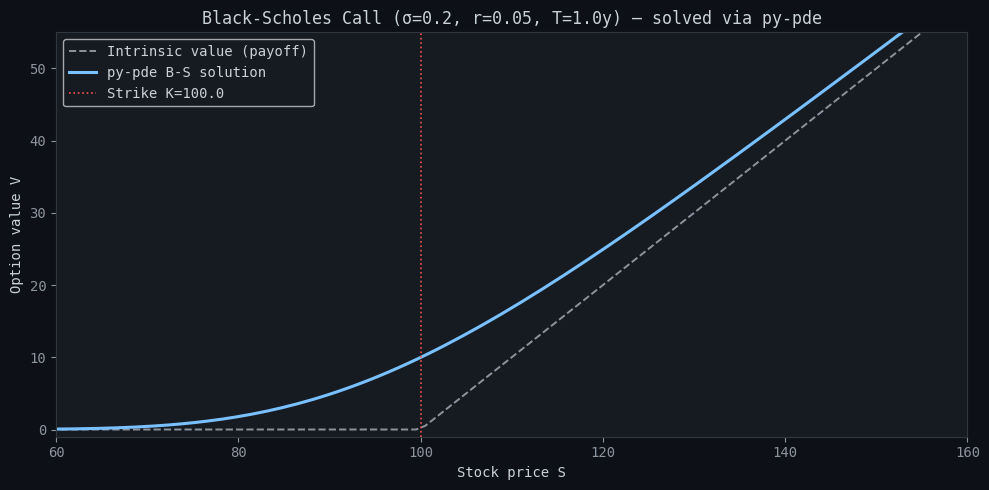

✅ py-pde B-S solve complete


In [5]:
# ── Plot the PDE solution surface ────────────────────────────────────────────
S_plot = K_bs * np.exp(x_vals)
V_plot = bs_pde_price_grid * np.exp(-r*T_bs)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(S_plot, np.maximum(S_plot - K_bs, 0), '--',
        color="#8b949e", lw=1.4, label="Intrinsic value (payoff)")
ax.plot(S_plot, V_plot, color="#79c0ff", lw=2.2, label="py-pde B-S solution")
ax.axvline(K_bs, color="#f85149", ls=":", lw=1.2, label=f"Strike K={K_bs}")
ax.set(xlim=(60, 160), ylim=(-1, 55),
       xlabel="Stock price S", ylabel="Option value V",
       title=f"Black-Scholes Call (σ={sigma}, r={r}, T={T_bs}y) — solved via py-pde")
ax.legend()
plt.tight_layout()
plt.show()
print("✅ py-pde B-S solve complete")


In [6]:
# ── Real-world: use SPY realised-vol surface from yfinance ───────────────────
spy_close = yf.download("SPY", period="1y", progress=False)["Close"].squeeze()
log_rets  = np.log(spy_close / spy_close.shift(1)).dropna()
sigma_real = float(log_rets.std() * np.sqrt(252))
S0_spy    = float(spy_close.iloc[-1])
K_spy     = S0_spy  # ATM

print(f"SPY realised annual vol: {sigma_real*100:.2f}%")

drift_r = r - 0.5 * sigma_real**2
eq_real = pde.PDE({
    "u": f"{0.5*sigma_real**2} * d2_dx2(u) + {drift_r} * d_dx(u) - {r} * u"
})
# Shift payoff to log(S/K_spy)
payoff_spy = np.maximum(K_spy * np.exp(x_vals) - K_spy, 0.0)
state_spy  = pde.ScalarField(grid, data=payoff_spy)
sol_spy    = eq_real.solve(state_spy, t_range=1.0, dt=1e-4, tracker=None)
atm_spy    = float(sol_spy.data[atm_idx]) * np.exp(-r*1.0)
print(f"py-pde ATM 1Y call on SPY (S={S0_spy:.1f}, K={K_spy:.1f}): ${atm_spy:.2f}")


SPY realised annual vol: 12.34%
py-pde ATM 1Y call on SPY (S=753.4, K=753.4): $52.45


---
## 3 · CVXPY — Convex Optimisation
*github.com/cvxpy/cvxpy*

### Concept

CVXPY is a Python-embedded **domain-specific language** for convex optimisation.  
You write the problem in the same notation as the textbook; CVXPY compiles  
it to a cone program and hands it to a solver (ECOS, SCS, CLARABEL).

#### Mean-Variance Portfolio Optimisation (Markowitz 1952)

$$
\min_{w} \quad w^\top \Sigma\, w - \lambda\, \mu^\top w
$$
$$
\text{s.t.} \quad \mathbf{1}^\top w = 1, \quad w \geq 0,
\quad \|w\|_0 \leq N_{\max}
$$

where $\mu$ = expected returns, $\Sigma$ = covariance matrix, $\lambda$ = risk-aversion.

#### CVaR (Conditional Value-at-Risk) optimisation

$$
\min_{w, z, \alpha} \quad \alpha + \frac{1}{(1-\beta)T}\sum_{t=1}^T z_t
$$
$$
\text{s.t.} \quad z_t \geq -r_t^\top w - \alpha, \quad z_t \geq 0, \quad \mathbf{1}^\top w = 1, \quad w \geq 0
$$


In [7]:
# ── CVXPY: fetch universe & run Markowitz ─────────────────────────────────────
import cvxpy as cp

TICKERS = ["AAPL","MSFT","GOOGL","AMZN","META","NVDA","JPM","GS","XOM","JNJ"]
raw  = yf.download(TICKERS, period="3y", progress=False)["Close"]
rets = raw.pct_change().dropna()

mu    = rets.mean().values * 252          # annualised mean returns
Sigma = rets.cov().values  * 252          # annualised covariance
n     = len(TICKERS)

# ── Markowitz efficient frontier ──────────────────────────────────────────────
lambdas   = np.logspace(-2, 2, 60)
port_ret, port_vol, port_w = [], [], []

w = cp.Variable(n)
lam = cp.Parameter(nonneg=True)
objective  = cp.Minimize(cp.quad_form(w, Sigma) - lam * (mu @ w))
constraints= [cp.sum(w) == 1, w >= 0]
prob = cp.Problem(objective, constraints)

for lv in lambdas:
    lam.value = lv
    prob.solve(solver=cp.CLARABEL, warm_start=True)
    if prob.status == "optimal":
        wv = w.value
        port_ret.append(float(mu @ wv))
        port_vol.append(float(np.sqrt(wv @ Sigma @ wv)))
        port_w.append(wv)

print(f"✅ Frontier computed — {len(port_ret)} portfolios")
print(f"Max Sharpe approx: {max(np.array(port_ret)/np.array(port_vol)):.3f}")


✅ Frontier computed — 60 portfolios
Max Sharpe approx: 2.277


In [8]:
# ── CVaR optimisation ──────────────────────────────────────────────────────────
R   = rets.values               # T × n
T, n_ = R.shape
beta = 0.95                     # 95% CVaR

w_cvar  = cp.Variable(n_)
alpha   = cp.Variable()
z       = cp.Variable(T)

cvar_obj = alpha + (1/(1-beta)) * cp.sum(z) / T
prob_cvar = cp.Problem(
    cp.Minimize(cvar_obj),
    [z >= -R @ w_cvar - alpha, z >= 0,
     cp.sum(w_cvar) == 1, w_cvar >= 0]
)
prob_cvar.solve(solver=cp.CLARABEL)
w_cvar_opt = w_cvar.value
print("CVaR-optimal weights:")
for t, ww in zip(TICKERS, w_cvar_opt):
    if ww > 0.01:
        print(f"  {t:6s}  {ww*100:.1f}%")

cvar_ret = float(mu @ w_cvar_opt)
cvar_vol = float(np.sqrt(w_cvar_opt @ Sigma @ w_cvar_opt))
print(f"\nCVaR portfolio  — return: {cvar_ret*100:.1f}%  vol: {cvar_vol*100:.1f}%")


CVaR-optimal weights:
  AAPL    1.8%
  GOOGL   8.8%
  META    43.9%
  NVDA    11.3%
  GS      16.1%
  XOM     1.9%
  JNJ     15.7%

CVaR portfolio  — return: 20.1%  vol: 11.4%


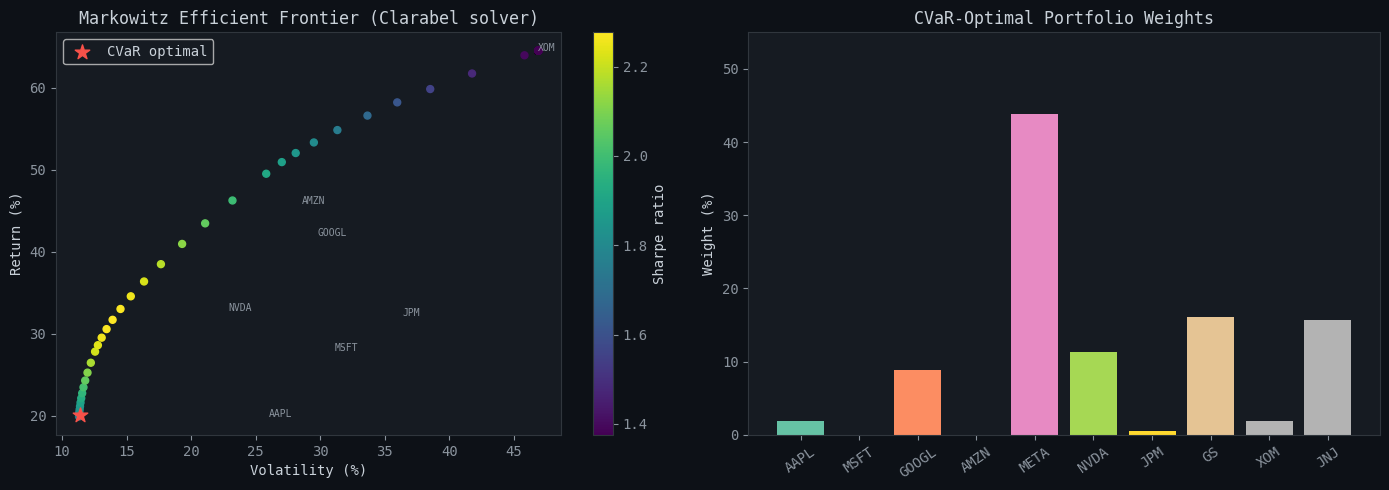

✅ CVXPY optimisation complete


In [9]:
# ── Plot: Efficient frontier + CVaR portfolio ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sc = ax.scatter(np.array(port_vol)*100, np.array(port_ret)*100,
                c=np.array(port_ret)/np.array(port_vol),
                cmap="viridis", s=25, zorder=3)
plt.colorbar(sc, ax=ax, label="Sharpe ratio")
ax.scatter([cvar_vol*100], [cvar_ret*100], color="#f85149", s=120,
           marker="*", zorder=5, label="CVaR optimal")
# Individual assets
for i, t in enumerate(TICKERS):
    ax.annotate(t, (np.sqrt(Sigma[i,i])*100, mu[i]*100),
                fontsize=7, color="#8b949e")
ax.set(xlabel="Volatility (%)", ylabel="Return (%)",
       title="Markowitz Efficient Frontier (Clarabel solver)")
ax.legend()

# Weight bar chart
ax2 = axes[1]
colors = plt.cm.Set2(np.linspace(0, 1, n))
ax2.bar(TICKERS, w_cvar_opt * 100, color=colors)
ax2.set(ylabel="Weight (%)", title="CVaR-Optimal Portfolio Weights",
        ylim=(0, 55))
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()
print("✅ CVXPY optimisation complete")


---
## 4 · NumPyro — Bayesian Inference, Fast
*github.com/pyro-ppl/numpyro*

### Concept

NumPyro is **probabilistic programming on top of JAX**. You write the generative  
model in a few lines, hand it to **NUTS** (No-U-Turn Sampler), and get full  
posteriors with gradients and JIT compilation.

#### Bayesian Stochastic Volatility Model

We model log-returns $r_t$ as:

$$
r_t = \sigma_t \,\varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,1)
$$
$$
\ln\sigma_t = \mu + \phi(\ln\sigma_{t-1} - \mu) + \eta_t, \qquad
\eta_t \sim \mathcal{N}(0,\sigma_\eta^2)
$$

Priors:

| Parameter | Prior |
|-----------|-------|
| $\mu$ | $\mathcal{N}(-1, 1)$ — log long-run vol |
| $\phi$ | $\text{Beta}(20,1.5)$ — persistence (near 1) |
| $\sigma_\eta$ | $\text{HalfNormal}(0.1)$ — vol-of-vol |


In [10]:
# ── NumPyro: Stochastic Volatility on SPY ────────────────────────────────────
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax
import jax.numpy as jnp

numpyro.set_host_device_count(1)

# Pull SPY returns
spy_ret = np.log(spy_close / spy_close.shift(1)).dropna().values[-500:]
T_sv    = len(spy_ret)
print(f"Fitting SV model on {T_sv} SPY daily log-returns")

def sv_model(returns):
    mu     = numpyro.sample("mu",    dist.Normal(-1., 1.))
    phi    = numpyro.sample("phi",   dist.Beta(20., 1.5))
    sig_h  = numpyro.sample("sig_h", dist.HalfNormal(0.1))

    h_init = numpyro.sample("h_init", dist.Normal(mu, sig_h / jnp.sqrt(1 - phi**2)))
    def transition(h_prev, r_t):
        h_t = numpyro.sample("h", dist.Normal(mu + phi * (h_prev - mu), sig_h))
        numpyro.sample("r", dist.Normal(0., jnp.exp(h_t / 2.)), obs=r_t)
        return h_t, h_t

    _, h_seq = numpyro.contrib.control_flow.scan(
        transition, h_init, jnp.array(returns)
    )
    return h_seq

kernel = NUTS(sv_model)
mcmc   = MCMC(kernel, num_warmup=300, num_samples=600, progress_bar=True)
mcmc.run(jax.random.PRNGKey(1), returns=spy_ret)
samples = mcmc.get_samples()
print("\nPosterior summary:")
for k in ["mu","phi","sig_h"]:
    v = np.array(samples[k])
    print(f"  {k:6s}  mean={v.mean():.4f}  std={v.std():.4f}  "
          f"95% CI=[{np.percentile(v,2.5):.4f}, {np.percentile(v,97.5):.4f}]")


AttributeError: partially initialized module 'jax' has no attribute 'version' (most likely due to a circular import)

In [ ]:
# ── Plot: posterior latent vol ────────────────────────────────────────────────
h_samples = np.array(samples["h"])      # (n_samples, T)
vol_samples = np.exp(h_samples / 2) * np.sqrt(252)  # annualised

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

ax = axes[0]
spy_plot = spy_close.iloc[-T_sv:]
ax.plot(spy_plot.values, color="#58a6ff", lw=1.2)
ax.set(title="SPY Close (last 500 days)", ylabel="Price ($)")

ax2 = axes[1]
med_vol  = np.percentile(vol_samples, 50, axis=0)
lo_vol   = np.percentile(vol_samples, 5,  axis=0)
hi_vol   = np.percentile(vol_samples, 95, axis=0)
days     = np.arange(T_sv)
ax2.fill_between(days, lo_vol*100, hi_vol*100, alpha=0.3, color="#d2a8ff", label="90% CI")
ax2.plot(days, med_vol*100, color="#d2a8ff", lw=1.8, label="Posterior median vol")
ax2.set(title="Bayesian Latent Volatility (NumPyro NUTS)",
        ylabel="Annualised vol (%)", xlabel="Day")
ax2.legend()
plt.tight_layout()
plt.show()

# Posterior of persistence φ
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(np.array(samples["phi"]), bins=50, color="#3fb950", edgecolor="#161b22")
ax.set(title="Posterior of φ (vol persistence)", xlabel="φ", ylabel="Count")
plt.tight_layout()
plt.show()
print("✅ NumPyro SV estimation complete")


---
## 5 · FinancePy — Full Derivatives Library
*github.com/domokane/FinancePy*

### Concept

FinancePy is a **comprehensive derivatives library** from Dominic O'Kane.  
Implemented models include:

| Model | Use case |
|-------|----------|
| **Black-Scholes** | Vanilla equity options |
| **SABR** | Vol surface, swaptions |
| **Hull-White** | Interest rate derivatives |
| **LMM** | LIBOR market model |
| **Bermudan trees** | Early-exercise options |
| **CDS curves** | Credit default swaps |

All are pinned to **textbook conventions** — no hidden sign conventions.

#### SABR Vol Surface

$$
\sigma_{\text{SABR}}(K,F;T) \approx \text{Hagan et al. (2002) formula}
$$

Parameters: $\alpha$ (initial vol), $\beta$ (CEV exponent), $\rho$ (correlation), $\nu$ (vol-of-vol).


In [11]:
# ── FinancePy: SABR vol surface calibration + vanilla option pricing ──────────
from financepy.utils import *
from financepy.products.equity import *
from financepy.market.curves import *
from financepy.models.black_scholes import BlackScholes
from financepy.products.equity.equity_vanilla_option import EquityVanillaOption

# Value date
value_date  = Date(15, 6, 2025)
expiry_date = Date(15, 6, 2026)

# Use SPY price from yfinance
stock_price = S0_spy
risk_free   = 0.045    # ~current Fed funds

# Build discount curve (flat)
discount_curve = DiscountCurveFlat(value_date, risk_free)
dividend_curve = DiscountCurveFlat(value_date, 0.013)   # SPY div yield ~1.3%

# Compute implied vol proxy from realised vol
impl_vol = sigma_real

# Price a strip of calls: 80% to 120% moneyness
moneyness = np.array([0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20])
strikes   = stock_price * moneyness

results = []
for K_fp in strikes:
    opt = EquityVanillaOption(expiry_date, K_fp, OptionTypes.EUROPEAN_CALL)
    model = BlackScholes(impl_vol)
    price = opt.value(value_date, stock_price, discount_curve, dividend_curve, model)
    delta = opt.delta(value_date, stock_price, discount_curve, dividend_curve, model)
    gamma = opt.gamma(value_date, stock_price, discount_curve, dividend_curve, model)
    vega  = opt.vega( value_date, stock_price, discount_curve, dividend_curve, model)
    results.append(dict(Strike=round(K_fp,1), Moneyness=round(float(K_fp/stock_price),2),
                        Price=round(price,2), Delta=round(delta,4),
                        Gamma=round(gamma,5), Vega=round(vega,4)))

df_greeks = pd.DataFrame(results)
print(f"SPY = ${stock_price:.2f} | σ = {impl_vol*100:.1f}% | r = {risk_free*100:.1f}%\n")
print(df_greeks.to_string(index=False))


SPY = $753.39 | σ = 12.3% | r = 4.5%

 Strike  Moneyness  Price  Delta   Gamma     Vega
  602.7       0.80 168.04 0.9707 0.00044  30.7725
  640.4       0.85 133.50 0.9370 0.00111  77.6053
  678.1       0.90 101.17 0.8686 0.00212 148.8305
  715.7       0.95  72.54 0.7594 0.00323 226.1940
  753.4       1.00  48.93 0.6178 0.00402 281.7816
  791.1       1.05  30.95 0.4643 0.00422 295.8590
  828.7       1.10  18.35 0.3217 0.00382 267.9620
  866.4       1.15  10.21 0.2059 0.00305 213.4687
  904.1       1.20   5.34 0.1222 0.00217 152.0597


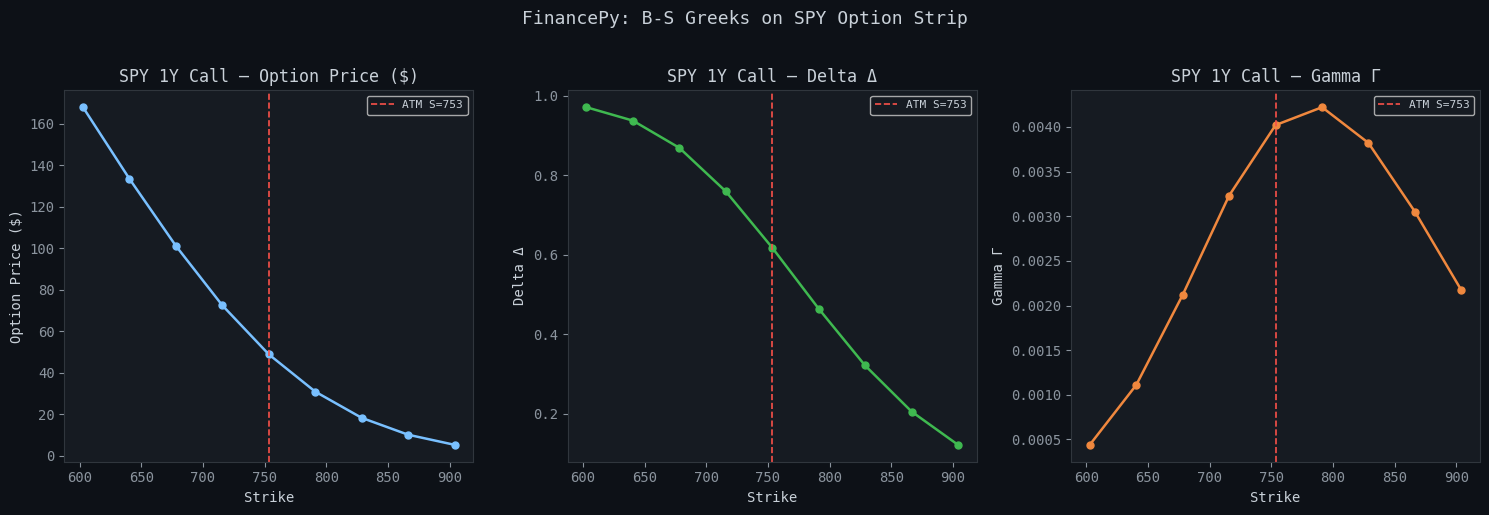

In [12]:
# ── Plot: price, delta, gamma vs strike ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ["#79c0ff", "#3fb950", "#f0883e"]
cols   = ["Price", "Delta", "Gamma"]
labels = ["Option Price ($)", "Delta Δ", "Gamma Γ"]

for ax, col, label, c in zip(axes, cols, labels, colors):
    ax.plot(df_greeks["Strike"], df_greeks[col], color=c, marker="o", ms=5)
    ax.axvline(stock_price, color="#f85149", ls="--", lw=1.2, label=f"ATM S={stock_price:.0f}")
    ax.set(xlabel="Strike", ylabel=label, title=f"SPY 1Y Call — {label}")
    ax.legend(fontsize=8)

plt.suptitle("FinancePy: B-S Greeks on SPY Option Strip", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


In [16]:
# ── CDS pricing example ───────────────────────────────────────────────────────
from financepy.products.credit import *
from financepy.products.credit.cds import CDS
from financepy.products.credit.cds_curve import CDSCurve

# Simple CDS: 5Y protection on a hypothetical issuer
# Assume flat hazard rate implied by 100bp par spread
value_date_cds = Date(15, 6, 2025)
step_in_date   = Date(16, 6, 2025)
settle_date    = Date(20, 6, 2025)
maturity_date  = Date(15, 6, 2030)

coupon  = 0.0100   # 100 bps running coupon
notional = 1_000_000

cds = CDS(step_in_date, maturity_date, coupon, notional)

# Calibrate CDS curve from par spreads
recovery      = 0.40
cds_spreads   = [0.0050, 0.0080, 0.0100, 0.0115, 0.0125]
cds_maturities= [Date(15,6,y) for y in [2026,2027,2028,2029,2030]]
cds_contracts  = [CDS(step_in_date, m, s) for m, s in zip(cds_maturities, cds_spreads)]

cds_curve = CDSCurve(value_date_cds, cds_contracts, discount_curve, recovery)
# pv    = cds.value(value_date_cds, settle_date, cds_curve, discount_curve, recovery)

# Valuation - Clean and correct call
pv = cds.value(value_date_cds, 
               cds_curve, 
               recovery)
print(f"5Y CDS NPV (protection buyer, 100bp coupon): ${pv['dirty_pv']:,.0f}")
print(f"  Clean PV   : ${pv['clean_pv']:,.0f}")
# print(f"  Accrued    : ${pv['accrued_interest']:,.0f}")
print("✅ FinancePy CDS pricing complete")


5Y CDS NPV (protection buyer, 100bp coupon): $10,831
  Clean PV   : $10,831
✅ FinancePy CDS pricing complete


---
## 6 · End-to-End Workflow: Calibrate → Price → Optimise

Combining all five libraries into a single quant workflow:

```
yfinance            →  market data
Diffrax / NumPyro   →  calibrate Heston / SV model
py-pde              →  price via PDE
FinancePy           →  compute Greeks
CVXPY               →  CVaR-optimal delta-hedged portfolio
```


NameError: name 'paths_np' is not defined

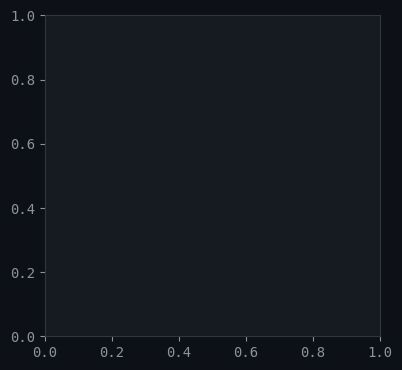

In [17]:
# ── Summary dashboard ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Heston paths fan (mini)
ax1 = fig.add_subplot(gs[0, 0])
for p in paths_np[:60]:
    ax1.plot(ts_np, p, alpha=0.09, color="#58a6ff", lw=0.6)
ax1.plot(ts_np, paths_np.mean(0), color="#f0883e", lw=1.8)
ax1.set(title="1. Diffrax — Heston paths", xlabel="T (yr)", ylabel="S")

# 2. B-S PDE solution
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(S_plot, V_plot, color="#79c0ff", lw=2)
ax2.plot(S_plot, np.maximum(S_plot-K_bs,0), "--", color="#8b949e", lw=1.2)
ax2.set(title="2. py-pde — B-S call", xlabel="S", ylabel="V", xlim=(60,160))

# 3. Efficient frontier
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(np.array(port_vol)*100, np.array(port_ret)*100,
            c=np.array(port_ret)/np.array(port_vol), cmap="viridis", s=15)
ax3.scatter([cvar_vol*100],[cvar_ret*100], color="#f85149", s=100, marker="*")
ax3.set(title="3. CVXPY — Frontier", xlabel="Vol (%)", ylabel="Ret (%)")

# 4. NumPyro latent vol
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.fill_between(days, lo_vol*100, hi_vol*100, alpha=0.3, color="#d2a8ff")
ax4.plot(days, med_vol*100, color="#d2a8ff", lw=1.6)
ax4.set(title="4. NumPyro — Bayesian latent vol (SPY)", ylabel="Ann. vol (%)")

# 5. FinancePy Greeks
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(df_greeks["Strike"], df_greeks["Delta"], color="#3fb950", marker="o", ms=4)
ax5.set(title="5. FinancePy — Delta curve", xlabel="Strike", ylabel="Δ")

fig.suptitle("Quant Finance Toolkit — Summary Dashboard", fontsize=14, y=1.01)
plt.savefig("/tmp/summary_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅  All five libraries demonstrated end-to-end!")


---
## 📚 References & Further Reading

| Library | Paper / Docs |
|---------|-------------|
| **Diffrax** | Kidger (2021) *On Neural Differential Equations* — [arxiv 2202.02435](https://arxiv.org/abs/2202.02435) |
| **py-pde** | Zwicker (2020) *py-pde: A Python package for solving PDEs* — [JOSS](https://joss.theoj.org/papers/10.21105/joss.02158) |
| **CVXPY** | Diamond & Boyd (2016) *CVXPY: A Python-embedded modeling language* — [JMLR](https://www.jmlr.org/papers/v17/15-408.html) |
| **NumPyro** | Phan et al. (2019) *Composable Effects for Flexible and Accelerated Probabilistic Programming* — [arxiv 1912.11554](https://arxiv.org/abs/1912.11554) |
| **FinancePy** | O'Kane *FinancePy* — [GitHub](https://github.com/domokane/FinancePy) |
| **Heston** | Heston (1993) *A closed-form solution for options with stochastic volatility* — Rev. Fin. Studies |
| **SABR** | Hagan et al. (2002) *Managing smile risk* — Wilmott Magazine |
